In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,StratifiedKFold,GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier,StackingClassifier,VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay


In [2]:
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"
df = pd.read_csv(url)
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [4]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


In [5]:
df=df.dropna(subset=['RainTomorrow'])

col_to_drop=['Evaporation','Sunshine','Cloud9am','Cloud3pm']
df=df.drop(columns=col_to_drop)

In [6]:
df=df.rename(columns={'RainToday':'RainYestarDay',
                      'RainTomorrow':'RainToday'})


In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.day
df=df.drop(columns=['Date'])

In [8]:
X=df.drop(columns=['RainToday'])
y=df['RainToday']

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [10]:
number_cols=X_train.select_dtypes(include=['float64']).columns.tolist()

#categorical columns
cat_cols=X_train.select_dtypes(include=['object']).columns.tolist()


In [11]:

numeric_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
categorical_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(transformers=[
    ('num',numeric_transformer,number_cols),
    ('cat',categorical_transformer,cat_cols)
])



In [12]:
rf_params={'n_estimators':100,'max_depth':10,'min_samples_split':5,'random_state':42}
xgb_params={'n_estimators':100,'max_depth':5,'learning_rate':0.1,'random_state':42}


meta_params={'C':1.0,'max_iter':1000,'random_state':42}


In [13]:
base_model=[
    ('rf',RandomForestClassifier(**rf_params)),
    ('xgb',XGBClassifier(**xgb_params)),
    ('svc',LinearSVC(C=1.0,random_state=42))
]

meta_model=LogisticRegression(**meta_params)
stacking_model=StackingClassifier(estimators=base_model,final_estimator=meta_model)



In [14]:
pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('stacking_model',stacking_model)
])


In [15]:
cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)


In [20]:
final_model=GridSearchCV(pipeline,param_grid={},cv=cv,scoring='accuracy',n_jobs=1,verbose=2)
final_model.fit(X_train,y_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END .................................................... total time= 1.9min
[CV] END .................................................... total time= 1.8min
[CV] END .................................................... total time= 1.8min


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['MinTemp',
                                                                          'MaxTemp',
                                                                          'Rainfall',
                                                                          'WindGustSpeed',
                                                                          'WindSpeed9am',
                                                                          'WindSpeed3pm',
                                                                          'Humidity9am',
                                                                          'Humidity3pm'...
                                                                                      max_cat_to_onehot=None,
                                                                                      max_delta_step=None,
                                                                                      max_depth=5,
                                                                                      max_leaves=None,
                                                                                      min_child_weight=None,
                                                                                      missing=nan,
                                                                                      monotone_constraints=None,
                                                                                      multi_strategy=None,
                                                                                      n_estimators=100,
                                                                                      n_jobs=None,
                                                                                      num_parallel_tree=None, ...)),
                                                                       ('svc',
                                                                        LinearSVC(random_state=42))],
                                                           final_estimator=LogisticRegression(max_iter=1000,
                                                                                              random_state=42)))]),
             n_jobs=1, param_grid={}, scoring='accuracy', verbose=2)

In [22]:
print('\n Best parametars found:',final_model.best_params_)
print('\n Best cross_validation score:{:.2f}'.format(final_model.best_score_))


 Best parametars found: {}

 Best cross_validation score:0.85


In [24]:
y_pred = final_model.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[20927  1137]
 [ 3053  3322]]
              precision    recall  f1-score   support

          No       0.87      0.95      0.91     22064
         Yes       0.75      0.52      0.61      6375

    accuracy                           0.85     28439
   macro avg       0.81      0.73      0.76     28439
weighted avg       0.84      0.85      0.84     28439



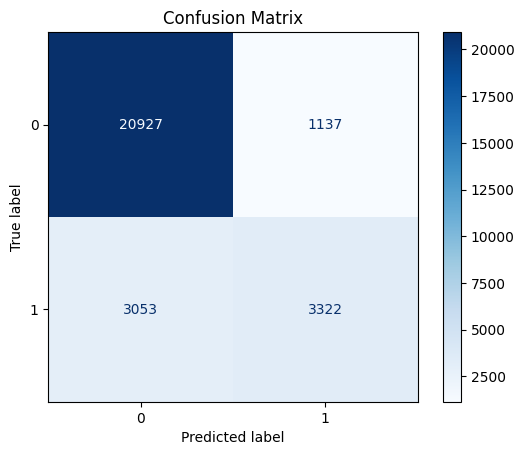

In [28]:
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [38]:
import joblib
from google.colab import files

# 1. حفظ الـ Pipeline الكامل (المعالجة Preprocessor + موديل الـ Stacking)
joblib.dump(final_model, 'weather_stacking_model.pkl')
print("Model Saved Successfully")

# 2. تنزيل الملف فوراً على جهازك
files.download('weather_stacking_model.pkl')

Model Saved Successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>